![imagen](./img/ejercicios.png)

# INFORMACIÓN DEL PROYECTO

### TÍTULO

In [102]:
#Escribe el título del proyecto en Markdown
TITULO = "Inflación vs poder adquisitivo"


### TEMA

In [ ]:
# Describe brevemente el tema del proyecto en Markdown
tema = "analizar la relación entre la inflación y el poder adquisitivo de la población en distintos países: España y UE"

### HIPÓTESIS

Define aquí lo que será la hipótesis de tu proyecto.
Deberás tener más de una, pero tu proyecto lo harás teniendo una principal hipótesis.

In [ ]:
hipotesis_1 = "Un aumento de los niveles de inflación se asocia con una reducción del poder adquisitivo de la población, reflejada en una menor capacidad económica medida a través del PIB per cápita."

hipotesis_2 = "El aumento de la inflación no siempre se ve acompañado por un incremento proporcional de los salarios, lo que puede provocar una pérdida de poder adquisitivo en la población."

hipotesis_3 = "¿exist relación inversa entre inflación y desempleo?"

COSAS QUE CREO QUE PUEDO SACAR O analizar:
Variables principales:
Tasa de inflación
PIB per cápita PPT
Indicador de salarios netos anuales
Tasa de desempleo

## OBTENCIÓN DE LOS DATOS

### DATASETS Y FUENTES ALTERNATIVAS DE DATOS

Incluye aquí una vista del dataset o datasets de los que partirás para poder evaluar tu hipótesis. <br>
También incluye el origen de estos datos y su fuente.

In [ ]:
# Fuente DONDE HE SACADO DATOS SOBRE INFLACION.
https://ec.europa.eu/eurostat/databrowser/view/prc_hicp_ainr/default/table?category=prc.prc_hicp.prc_hicp_ecoicop2 

# Fuente donde he sacado datos sobre PIB per cápita PPT( Paridad del Poder Adquisitivo
https://ec.europa.eu/eurostat/databrowser/view/tec00114/default/table?lang=en 

# Fuente donde he sacado datos sobre el indicador de salario neto anual
https://ec.europa.eu/eurostat/databrowser/view/earn_nt_net/default/table?lang=en&utm_source=chatgpt.com

# Fuente donde he sacado datos sobre tasa de desempleo
https://ec.europa.eu/eurostat/databrowser/view/une_rt_a__custom_20846094/default/table


In [451]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# guarda en variables los datasets y su fuente
df_inflacion = pd.read_csv("./data/inflacion europa_2000-2025.tsv", sep= "\t")
fuente_1 = "EUROSTAT"

df_pib_per_capita = pd.read_csv("./data/GDP_per_capita_in_PPS_europa_2014-2025.tsv", sep= "\t")
fuente_2 = "EUROSTAT"

df_salario_neto = pd.read_csv("./data/salarios_netos_europa_2000-2024.tsv", sep= "\t")
fuente_2 = "EUROSTAT"

df_tasa_desempleo = pd.read_csv("./data/tasa_desempleo_europa_2003_2025.tsv", sep= "\t")
fuente_2 = "EUROSTAT"


Muestra mediante un head() los principales datasets con los que vas a trabajar

In [310]:
import pandas as pd

In [311]:
# dataset inflacion
df_inflacion
df_inflacion.head()

,"freq,unit,coicop18,geo\TIME_PERIOD",2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,"A,RCH_A_AVG,TOTAL,AT",2.0,2.3,1.7,1.3,2.0,2.1,1.7,2.2,3.2,...,1.0,2.2,2.1,1.5,1.4,2.8,8.6,7.7,2.9,3.6
1,"A,RCH_A_AVG,TOTAL,BE",2.7,2.4,1.5,1.5,1.9,2.5,2.3,1.8,4.5,...,1.8,2.2,2.3,1.3,0.4,3.2,10.3,2.3,4.3,3.0
2,"A,RCH_A_AVG,TOTAL,BG",10.3,7.4,5.8,2.3,6.1,6.0,7.4,7.6,12.0,...,-1.3,1.2,2.6,2.5,1.2,2.8,13.0,8.6,2.6,3.5
3,"A,RCH_A_AVG,TOTAL,CH",:,:,:,:,:,:,:,0.8,2.4,...,-0.5,0.6,0.9,0.4,-0.8,0.5,2.7,2.3,1.1,0.1
4,"A,RCH_A_AVG,TOTAL,CY",4.9,2.0,2.8,4.0,1.9,2.0,2.2,2.2,4.4,...,-1.2,0.7,0.8,0.5,-1.1,2.3,8.1,3.9,2.3,0.8


In [312]:
df_inflacion.info()

<class 'pandas.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 27 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   freq,unit,coicop18,geo\TIME_PERIOD  31 non-null     str    
 1   2000                                31 non-null     str    
 2   2001                                31 non-null     str    
 3   2002                                31 non-null     str    
 4   2003                                31 non-null     str    
 5   2004                                31 non-null     str    
 6   2005                                31 non-null     str    
 7   2006                                31 non-null     str    
 8   2007                                31 non-null     str    
 9   2008                                31 non-null     str    
 10  2009                                31 non-null     str    
 11  2010                                31 non-null     str   

In [313]:
#1.Aqui hago una copia del dataframe original
df_inflacion_clean= df_inflacion.copy() 

#2. Renombro la primera columna "freq,unit,coicop18,geo\TIME_PERIOD" y la cambio a "info" para trabajar más fácil.
df_inflacion_clean = df_inflacion_clean.rename(columns={
    "freq,unit,coicop18,geo\TIME_PERIOD": "info"})
df_inflacion_clean

,info,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,"A,RCH_A_AVG,TOTAL,AT",2.0,2.3,1.7,1.3,2.0,2.1,1.7,2.2,3.2,...,1.0,2.2,2.1,1.5,1.4,2.8,8.6,7.7,2.9,3.6
1,"A,RCH_A_AVG,TOTAL,BE",2.7,2.4,1.5,1.5,1.9,2.5,2.3,1.8,4.5,...,1.8,2.2,2.3,1.3,0.4,3.2,10.3,2.3,4.3,3.0
2,"A,RCH_A_AVG,TOTAL,BG",10.3,7.4,5.8,2.3,6.1,6.0,7.4,7.6,12.0,...,-1.3,1.2,2.6,2.5,1.2,2.8,13.0,8.6,2.6,3.5
3,"A,RCH_A_AVG,TOTAL,CH",:,:,:,:,:,:,:,0.8,2.4,...,-0.5,0.6,0.9,0.4,-0.8,0.5,2.7,2.3,1.1,0.1
4,"A,RCH_A_AVG,TOTAL,CY",4.9,2.0,2.8,4.0,1.9,2.0,2.2,2.2,4.4,...,-1.2,0.7,0.8,0.5,-1.1,2.3,8.1,3.9,2.3,0.8
5,"A,RCH_A_AVG,TOTAL,CZ",3.9,4.5,1.4,-0.1,2.6,1.6,2.0,2.9,6.3,...,0.7,2.5,1.9,2.6,3.3,3.3,14.8,12.0,2.7,2.3
6,"A,RCH_A_AVG,TOTAL,DE",1.4,1.9,1.3,1.1,1.8,1.9,1.8,2.3,2.8,...,0.4,1.7,1.9,1.4,0.4,3.2,8.7,6.0,2.5,2.3
7,"A,RCH_A_AVG,TOTAL,DK",2.7,2.3,2.4,2.0,0.9,1.7,1.9,1.7,3.6,...,0.0,1.1,0.7,0.7,0.3,1.9,8.6,3.4,1.3,1.8
8,"A,RCH_A_AVG,TOTAL,EE",3.9,5.6,3.6,1.4,3.0,4.1,4.4,6.7,10.6,...,0.8,3.7,3.4,2.3,-0.6,4.5,19.4,9.1,3.7,4.8
9,"A,RCH_A_AVG,TOTAL,EL",2.9,3.6,3.9,3.5,3.0,3.5,3.3,3.0,4.2,...,0.0,1.1,0.8,0.5,-1.3,0.6,9.3,4.2,3.0,2.9


In [314]:
#3. Separo la columna Info en varias columnas:
df_inflacion_clean[['freq', 'unit', 'coicop', 'country']] = df_inflacion_clean['info'].str.split(',', expand = True) #.str.split(',') → separa el texto por comas, y expand=TRue crea nuevas columnas

#4. Elimino  la columna original "info" (ya no la necesitamos):
df_inflacion_clean = df_inflacion_clean.drop(columns = ['info'])
df_inflacion_clean

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2020,2021,2022,2023,2024,2025,freq,unit,coicop,country
0,2.0,2.3,1.7,1.3,2.0,2.1,1.7,2.2,3.2,0.4,...,1.4,2.8,8.6,7.7,2.9,3.6,A,RCH_A_AVG,TOTAL,AT
1,2.7,2.4,1.5,1.5,1.9,2.5,2.3,1.8,4.5,0.0,...,0.4,3.2,10.3,2.3,4.3,3.0,A,RCH_A_AVG,TOTAL,BE
2,10.3,7.4,5.8,2.3,6.1,6.0,7.4,7.6,12.0,2.5,...,1.2,2.8,13.0,8.6,2.6,3.5,A,RCH_A_AVG,TOTAL,BG
3,:,:,:,:,:,:,:,0.8,2.4,-0.7,...,-0.8,0.5,2.7,2.3,1.1,0.1,A,RCH_A_AVG,TOTAL,CH
4,4.9,2.0,2.8,4.0,1.9,2.0,2.2,2.2,4.4,0.2,...,-1.1,2.3,8.1,3.9,2.3,0.8,A,RCH_A_AVG,TOTAL,CY
5,3.9,4.5,1.4,-0.1,2.6,1.6,2.0,2.9,6.3,0.6,...,3.3,3.3,14.8,12.0,2.7,2.3,A,RCH_A_AVG,TOTAL,CZ
6,1.4,1.9,1.3,1.1,1.8,1.9,1.8,2.3,2.8,0.2,...,0.4,3.2,8.7,6.0,2.5,2.3,A,RCH_A_AVG,TOTAL,DE
7,2.7,2.3,2.4,2.0,0.9,1.7,1.9,1.7,3.6,1.1,...,0.3,1.9,8.6,3.4,1.3,1.8,A,RCH_A_AVG,TOTAL,DK
8,3.9,5.6,3.6,1.4,3.0,4.1,4.4,6.7,10.6,0.2,...,-0.6,4.5,19.4,9.1,3.7,4.8,A,RCH_A_AVG,TOTAL,EE
9,2.9,3.6,3.9,3.5,3.0,3.5,3.3,3.0,4.2,1.3,...,-1.3,0.6,9.3,4.2,3.0,2.9,A,RCH_A_AVG,TOTAL,EL


In [315]:
#5. Convertir el dataset de formato ancho a largo.

df_inflacion_long = df_inflacion_clean.melt(
    id_vars=['freq', 'unit', 'coicop', 'country'],
    var_name='year',
    value_name='inflation')
df_inflacion_long
# Columnas explicadas:
    #freq: frecuencia de la medida, A significa anual.
    #unit: unidad y tipo de dato, RCH_A_AVG es la inflación media anual (la tasa de cambio anual promedio).
    #coicop: categoría del consumo, TOTAL indica que es el total general (sin subdivisiones).
    #geo: código del país (DE = Alemania, ES = España, FR = Francia, EU = Unión Europea).
    #year: año al que corresponde el dato (2000, 2001, ..., 2025).
    #inflacion: valor numérico(%) de la inflación para ese país y año.

,freq,unit,coicop,country,year,inflation
0,A,RCH_A_AVG,TOTAL,AT,2000,2.0
1,A,RCH_A_AVG,TOTAL,BE,2000,2.7
2,A,RCH_A_AVG,TOTAL,BG,2000,10.3
3,A,RCH_A_AVG,TOTAL,CH,2000,:
4,A,RCH_A_AVG,TOTAL,CY,2000,4.9
...,...,...,...,...,...,...
801,A,RCH_A_AVG,TOTAL,RO,2025,6.8
802,A,RCH_A_AVG,TOTAL,SE,2025,2.6
803,A,RCH_A_AVG,TOTAL,SI,2025,2.5
804,A,RCH_A_AVG,TOTAL,SK,2025,4.2


In [316]:
#6. Ordenamos los datos
df_inflacion_long = df_inflacion_long.sort_values(by= ['country','year']) 
df_inflacion_long

,freq,unit,coicop,country,year,inflation
0,A,RCH_A_AVG,TOTAL,AT,2000,2.0
31,A,RCH_A_AVG,TOTAL,AT,2001,2.3
62,A,RCH_A_AVG,TOTAL,AT,2002,1.7
93,A,RCH_A_AVG,TOTAL,AT,2003,1.3
124,A,RCH_A_AVG,TOTAL,AT,2004,2.0
...,...,...,...,...,...,...
681,A,RCH_A_AVG,TOTAL,UK,2021,:
712,A,RCH_A_AVG,TOTAL,UK,2022,:
743,A,RCH_A_AVG,TOTAL,UK,2023,:
774,A,RCH_A_AVG,TOTAL,UK,2024,:


In [317]:
df_inflacion_long.info()

<class 'pandas.DataFrame'>
Index: 806 entries, 0 to 805
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   freq       806 non-null    str   
 1   unit       806 non-null    str   
 2   coicop     806 non-null    str   
 3   country    806 non-null    str   
 4   year       806 non-null    str   
 5   inflation  806 non-null    object
dtypes: object(1), str(5)
memory usage: 44.1+ KB


In [318]:
#7. Convierto el año a número entero, importante para gráficas y análisis.
df_inflacion_long['year'] = df_inflacion_long['year'].astype(int)
df_inflacion_long

,freq,unit,coicop,country,year,inflation
0,A,RCH_A_AVG,TOTAL,AT,2000,2.0
31,A,RCH_A_AVG,TOTAL,AT,2001,2.3
62,A,RCH_A_AVG,TOTAL,AT,2002,1.7
93,A,RCH_A_AVG,TOTAL,AT,2003,1.3
124,A,RCH_A_AVG,TOTAL,AT,2004,2.0
...,...,...,...,...,...,...
681,A,RCH_A_AVG,TOTAL,UK,2021,:
712,A,RCH_A_AVG,TOTAL,UK,2022,:
743,A,RCH_A_AVG,TOTAL,UK,2023,:
774,A,RCH_A_AVG,TOTAL,UK,2024,:


In [319]:
#8. Elimino las primeras 3 columnas , ya que en ellas no viene información relevante para mi análisis:
df_inflacion_long = df_inflacion_long.drop(df_inflacion_long.columns[:3], axis=1) #axis 1 undica que son columnas

In [320]:
df_inflacion_long.info() 

<class 'pandas.DataFrame'>
Index: 806 entries, 0 to 805
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   country    806 non-null    str   
 1   year       806 non-null    int64 
 2   inflation  806 non-null    object
dtypes: int64(1), object(1), str(1)
memory usage: 25.2+ KB


In [342]:
#. Convertir la columna inflation a numéro usando pd.to_numeric.
df_inflacion_long['inflation'] = pd.to_numeric(df_inflacion_long['inflation'], errors='coerce') #con errors='coerce' para que si hay  valores raros me los convierta en NAn)
df_inflacion_long

,country,year,inflation
0,AT,2000,2.0
31,AT,2001,2.3
62,AT,2002,1.7
93,AT,2003,1.3
124,AT,2004,2.0
...,...,...,...
681,UK,2021,NaN
712,UK,2022,NaN
743,UK,2023,NaN
774,UK,2024,NaN


In [ ]:
#9.1 una vez que he hecho la conversion, reviso cuántos valores NaN hay tras la conversion.
print(df_inflacion_long.isna().sum())
# print(df_inflacion_long.head())
# df_inflacion_long['inflation'].dtype
#con esto veo en que países y años  tengo valores Nan.
df_inflacion_long[df_inflacion_long["inflation"].isna()][["country", "year"]]

#Para verlo mejor, saco uan lista de todos los años donde hay NAn por país, para ello voy a hacer lo siguiente:
df_inflacion_long[df_inflacion_long['inflation'].isna()].groupby('country')['year'].apply(list)
"""conclusion: veo que todos los valores Nan , estan en países que no forman parte de la UE:
Uk salió de la UE(Brexit),y CH(Suiza),NO(Noruega) y IS(Islandia) no son países de la UE. 
Por lo tanto, voy a proceder a eliminar esos países por complero, ya que mi análisis lo voy a centrar en los paises que sí fortan parte de la UE.
"""



country       0
year          0
inflation    33
dtype: int64


country
CH           [2000, 2001, 2002, 2003, 2004, 2005, 2006]
IS    [2000, 2001, 2002, 2003, 2004, 2005, 2006, 200...
NO                                         [2000, 2001]
UK                 [2020, 2021, 2022, 2023, 2024, 2025]
Name: year, dtype: object

In [387]:
#10. eliminar NAN: países; UK, CH, No y IS:
#10.1. países con NAN:
paises_con_nan = df_inflacion_long[df_inflacion_long['inflation'].isna()]['country'].unique()
print(paises_con_nan) #me saca una lista de los países con nan.
#10.2. eliminar:
"""
Eliminación de países con valores faltantes (NaN) en la variable de inflación

# Filtramos el dataframe para quedarnos únicamente con los países
# que NO están en la lista de países con valores NaN (paises_con_nan).

# .isin(paises_con_nan) → identifica las filas cuyo país está en la lista
# ~ (negación) → invierte la condición (nos quedamos con los que NO están)
# 
# Resultado: se eliminan del dataset todos los países con datos incompletos
# para asegurar consistencia en el análisis posterior.
"""
df_inflacion_long = df_inflacion_long[~df_inflacion_long["country"].isin(paises_con_nan)]
print(df_inflacion_long.isna().sum()) #REVISO QUE NO HAYA  QUEDADO NINGUN NAN.
df_inflacion_long.info()

<StringArray>
[]
Length: 0, dtype: str
country      0
year         0
inflation    0
dtype: int64
<class 'pandas.DataFrame'>
Index: 702 entries, 0 to 804
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    702 non-null    str    
 1   year       702 non-null    int64  
 2   inflation  702 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 21.9 KB


In [541]:
df_inflacion_long

,country,year,inflation
0,AT,2000,2.0
31,AT,2001,2.3
62,AT,2002,1.7
93,AT,2003,1.3
124,AT,2004,2.0
...,...,...,...
680,SK,2021,2.8
711,SK,2022,12.1
742,SK,2023,11.0
773,SK,2024,3.2


DATASET PIB PER CAPITA

In [348]:
#dataset PIB per capita en paridad de poder adquisitivo(PPA).
df_pib_per_capita
df_pib_per_capita.head()


,"freq,indic_ppp,ppp_cat18,geo\TIME_PERIOD",2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,"A,VI_PPS_EU27_2020_HAB,GDP,AT",129,128,128,125,126,124,123,121,123,121,119,117 p
1,"A,VI_PPS_EU27_2020_HAB,GDP,BE",121,119,118,117,116,117,118,117,118,118,117 p,115 p
2,"A,VI_PPS_EU27_2020_HAB,GDP,BG",48,49,51,52,53,55,57,60,62,63,66,68 p
3,"A,VI_PPS_EU27_2020_HAB,GDP,CH",173,172,167,161,160,155,156,161,161,154 p,151 p,:
4,"A,VI_PPS_EU27_2020_HAB,GDP,CY",80,81,86,88,89,91,89,92,95,97,99 p,98 p


In [349]:
df_pib_per_capita.info()

<class 'pandas.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 13 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   freq,indic_ppp,ppp_cat18,geo\TIME_PERIOD  31 non-null     str  
 1   2014                                      31 non-null     int64
 2   2015                                      31 non-null     int64
 3   2016                                      31 non-null     int64
 4   2017                                      31 non-null     int64
 5   2018                                      31 non-null     int64
 6   2019                                      31 non-null     int64
 7   2020                                      31 non-null     int64
 8   2021                                      31 non-null     int64
 9   2022                                      31 non-null     str  
 10  2023                                      31 non-null     str  
 11  2024  

In [350]:
#1.Aqui hago una copia del dataframe original
df_pib_per_capita_clean=df_pib_per_capita.copy() 

In [351]:
#2. Renombro la primera columna "freq,indic_ppp,ppp_cat18," y la cambio a "info" para trabajar más fácil.

df_pib_per_capita_clean = df_pib_per_capita_clean.rename(columns={
    "freq,indic_ppp,ppp_cat18,geo\TIME_PERIOD": "info"})
df_pib_per_capita_clean

,info,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,"A,VI_PPS_EU27_2020_HAB,GDP,AT",129,128,128,125,126,124,123,121,123,121,119,117 p
1,"A,VI_PPS_EU27_2020_HAB,GDP,BE",121,119,118,117,116,117,118,117,118,118,117 p,115 p
2,"A,VI_PPS_EU27_2020_HAB,GDP,BG",48,49,51,52,53,55,57,60,62,63,66,68 p
3,"A,VI_PPS_EU27_2020_HAB,GDP,CH",173,172,167,161,160,155,156,161,161,154 p,151 p,:
4,"A,VI_PPS_EU27_2020_HAB,GDP,CY",80,81,86,88,89,91,89,92,95,97,99 p,98 p
5,"A,VI_PPS_EU27_2020_HAB,GDP,CZ",88,89,89,92,93,95,96,92,90,91,91,92 p
6,"A,VI_PPS_EU27_2020_HAB,GDP,DE",128,126,126,126,125,122,123,120,120 p,118 p,116 p,115 p
7,"A,VI_PPS_EU27_2020_HAB,GDP,DK",128,127,126,128,127,125,132,133,134,126,127,127 p
8,"A,VI_PPS_EU27_2020_HAB,GDP,EE",78,77,78,80,82,84,85,85,83,80,79,79 p
9,"A,VI_PPS_EU27_2020_HAB,GDP,EL",71,69,67,67,66,66,62,64,66,68 p,69 p,68 p


In [352]:
#3. Separo la columna Info en varias columnas:
df_pib_per_capita_clean[['freq', 'indic_ppp', 'ppp_cat18', 'country']] = df_pib_per_capita_clean['info'].str.split(',', expand = True) #.str.split(',') → separa el texto por comas, y expand=TRue crea nuevas columnas

#4 Elimino  la columna original "info" (ya no la necesitamos):
df_pib_per_capita_clean = df_pib_per_capita_clean.drop(columns = ['info'])
df_pib_per_capita_clean

,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,freq,indic_ppp,ppp_cat18,country
0,129,128,128,125,126,124,123,121,123,121,119,117 p,A,VI_PPS_EU27_2020_HAB,GDP,AT
1,121,119,118,117,116,117,118,117,118,118,117 p,115 p,A,VI_PPS_EU27_2020_HAB,GDP,BE
2,48,49,51,52,53,55,57,60,62,63,66,68 p,A,VI_PPS_EU27_2020_HAB,GDP,BG
3,173,172,167,161,160,155,156,161,161,154 p,151 p,:,A,VI_PPS_EU27_2020_HAB,GDP,CH
4,80,81,86,88,89,91,89,92,95,97,99 p,98 p,A,VI_PPS_EU27_2020_HAB,GDP,CY
5,88,89,89,92,93,95,96,92,90,91,91,92 p,A,VI_PPS_EU27_2020_HAB,GDP,CZ
6,128,126,126,126,125,122,123,120,120 p,118 p,116 p,115 p,A,VI_PPS_EU27_2020_HAB,GDP,DE
7,128,127,126,128,127,125,132,133,134,126,127,127 p,A,VI_PPS_EU27_2020_HAB,GDP,DK
8,78,77,78,80,82,84,85,85,83,80,79,79 p,A,VI_PPS_EU27_2020_HAB,GDP,EE
9,71,69,67,67,66,66,62,64,66,68 p,69 p,68 p,A,VI_PPS_EU27_2020_HAB,GDP,EL


In [353]:
#5. Convertir el dataset de formato ancho a largo.
df_pib_per_capita_clean = df_pib_per_capita_clean.melt(
    id_vars=['freq', 'indic_ppp', 'ppp_cat18', 'country'],
    var_name='year',
    value_name='GDP_per_capita')
df_pib_per_capita_clean


,freq,indic_ppp,ppp_cat18,country,year,GDP_per_capita
0,A,VI_PPS_EU27_2020_HAB,GDP,AT,2014,129
1,A,VI_PPS_EU27_2020_HAB,GDP,BE,2014,121
2,A,VI_PPS_EU27_2020_HAB,GDP,BG,2014,48
3,A,VI_PPS_EU27_2020_HAB,GDP,CH,2014,173
4,A,VI_PPS_EU27_2020_HAB,GDP,CY,2014,80
...,...,...,...,...,...,...
367,A,VI_PPS_EU27_2020_HAB,GDP,RO,2025,78 p
368,A,VI_PPS_EU27_2020_HAB,GDP,SE,2025,110 p
369,A,VI_PPS_EU27_2020_HAB,GDP,SI,2025,91 p
370,A,VI_PPS_EU27_2020_HAB,GDP,SK,2025,75 p


In [354]:
#6. Ordenamos los datos por país y año.
df_pib_per_capita_clean = df_pib_per_capita_clean.sort_values(by= ['country','year']) 
df_pib_per_capita_clean


,freq,indic_ppp,ppp_cat18,country,year,GDP_per_capita
0,A,VI_PPS_EU27_2020_HAB,GDP,AT,2014,129
31,A,VI_PPS_EU27_2020_HAB,GDP,AT,2015,128
62,A,VI_PPS_EU27_2020_HAB,GDP,AT,2016,128
93,A,VI_PPS_EU27_2020_HAB,GDP,AT,2017,125
124,A,VI_PPS_EU27_2020_HAB,GDP,AT,2018,126
...,...,...,...,...,...,...
247,A,VI_PPS_EU27_2020_HAB,GDP,UK,2021,100
278,A,VI_PPS_EU27_2020_HAB,GDP,UK,2022,103
309,A,VI_PPS_EU27_2020_HAB,GDP,UK,2023,99
340,A,VI_PPS_EU27_2020_HAB,GDP,UK,2024,99


In [356]:
# 7. Convierto el año a número entero, importante para gráficas y análisis.
df_pib_per_capita_clean['year'] = df_pib_per_capita_clean['year'].astype(int)
df_pib_per_capita_clean

,freq,indic_ppp,ppp_cat18,country,year,GDP_per_capita
0,A,VI_PPS_EU27_2020_HAB,GDP,AT,2014,129
31,A,VI_PPS_EU27_2020_HAB,GDP,AT,2015,128
62,A,VI_PPS_EU27_2020_HAB,GDP,AT,2016,128
93,A,VI_PPS_EU27_2020_HAB,GDP,AT,2017,125
124,A,VI_PPS_EU27_2020_HAB,GDP,AT,2018,126
...,...,...,...,...,...,...
247,A,VI_PPS_EU27_2020_HAB,GDP,UK,2021,100
278,A,VI_PPS_EU27_2020_HAB,GDP,UK,2022,103
309,A,VI_PPS_EU27_2020_HAB,GDP,UK,2023,99
340,A,VI_PPS_EU27_2020_HAB,GDP,UK,2024,99


In [357]:
#Elimino las primeras 3 columnas y al igual que el anterior dataset de inflacion estas columnas no viene info relevante.

df_pib_per_capita_clean = df_pib_per_capita_clean.drop(df_pib_per_capita_clean.columns[:3], axis=1) #axis 1 undica que son columnas
pib_per_capita_clean

,country,year,GDP_per_capita
0,AT,2014,129
31,AT,2015,128
62,AT,2016,128
93,AT,2017,125
124,AT,2018,126
...,...,...,...
247,UK,2021,100
278,UK,2022,103
309,UK,2023,99
340,UK,2024,99


In [358]:
#8.en columna GDP_PER_CAPITA tengo valores con una "p" (valor provisional), voy a quitarlo, haciendo los siguientes pasos:
#8.1. primero, pasar toda la columna a str por seguridad(porque mis datos viene mezclados srt, text,símbolos,y si hago replace directamente me peude dar error).
df_pib_per_capita_clean["GDP_per_capita"] = df_pib_per_capita_clean["GDP_per_capita"].astype(str)
#8.2 limpiar "p":
df_pib_per_capita_clean["GDP_per_capita"] = df_pib_per_capita_clean["GDP_per_capita"].str.replace(" p", "", regex=False) # quitar " p"

df_pib_per_capita_clean.info()


<class 'pandas.DataFrame'>
Index: 372 entries, 0 to 371
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   country         372 non-null    str  
 1   year            372 non-null    int64
 2   GDP_per_capita  372 non-null    str  
dtypes: int64(1), str(2)
memory usage: 11.6 KB


In [375]:
#9. Convertir la columna GDP_per_capita a numéro usando pd.to_numeric.

df_pib_per_capita_clean['GDP_per_capita'] = pd.to_numeric(df_pib_per_capita_clean['GDP_per_capita'], errors='coerce') #con errors='coerce' para que si hay  valores raros ":" me los convierta en NAn)

df_pib_per_capita_clean.info()



<class 'pandas.DataFrame'>
Index: 372 entries, 0 to 371
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         372 non-null    str    
 1   year            372 non-null    int64  
 2   GDP_per_capita  368 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 11.6 KB


In [376]:
#9.1 una vez que he hecho la conversion, reviso cuántos valores NaN hay tras la conversion.
print(df_pib_per_capita_clean.isna().sum())#Miro a ver cuantos valores Nan tengo en mi dataset.

#Con esto veo en que países y años tengo valores Nan.
print(df_pib_per_capita_clean[df_pib_per_capita_clean["GDP_per_capita"].isna()][["country", "year"]])

#Para verlo mejor, saco uan lista de todos los años donde hay NAn por país, para ello voy a hacer lo siguiente:
print(df_pib_per_capita_clean[df_pib_per_capita_clean['GDP_per_capita'].isna()].groupby('country')['year'].apply(list))

"""
conclusion:Al igual que el anterior dataset todos los valores Nan , estan en países que no forman parte de la UE:
Uk salió de la UE(Brexit),y CH(Suiza),NO(Noruega) y IS(Islandia) no son países de la UE. 
Por lo tanto,ya a proceder a eliminarlos por completo, ya que mi análisis lo voy a centrar en los paises que sí forman parte de la UE.
"""

country           0
year              0
GDP_per_capita    4
dtype: int64
    country  year
344      CH  2025
357      IS  2025
364      NO  2025
371      UK  2025
country
CH    [2025]
IS    [2025]
NO    [2025]
UK    [2025]
Name: year, dtype: object


'\nconclusion:Al igual que el anterior dataset todos los valores Nan , estan en países que no forman parte de la UE:\nUk salió de la UE(Brexit),y CH(Suiza),NO(Noruega) y IS(Islandia) no son países de la UE. \nPor lo tanto,ya a proceder a eliminarlos por completo, ya que mi análisis lo voy a centrar en los paises que sí forman parte de la UE.\n'

In [ ]:
#10.Eliminar NAN: países; UK, CH, No y IS:
#10.1. Saco una lista de países con NAN y me la guardo en una variable:
paises_con_nan_GDP = df_pib_per_capita_clean[df_pib_per_capita_clean['GDP_per_capita'].isna()]['country'].unique()
print(paises_con_nan_GDP) #me saca una lista de los países con nan.

#10.2. eliminar:
""" Eliminación de países con valores faltantes (NaN) en la variable de pib_per_capita
Filtramos el dataframe para quedarnos únicamente con los países
que NO están en la lista de países con valores NaN (paises_con_nan_GDP).

# .isin(paises_con_nan_GDP) → identifica las filas cuyo país está en la lista
# ~ (negación) → invierte la condición (nos quedamos con los que NO están)

# Resultado: se eliminan del dataset todos los países con datos incompletos
# para asegurar consistencia en el análisis posterior.
"""
df_pib_per_capita_clean = df_pib_per_capita_clean[~df_pib_per_capita_clean["country"].isin(paises_con_nan_GDP)]
print(df_pib_per_capita_clean.isna().sum())# REVISO QUE NO  HAYA QUEDADO NINGUN NAN.
df_pib_per_capita_clean

<StringArray>
[]
Length: 0, dtype: str
country           0
year              0
GDP_per_capita    0
dtype: int64


,country,year,GDP_per_capita
0,AT,2014,129.0
31,AT,2015,128.0
62,AT,2016,128.0
93,AT,2017,125.0
124,AT,2018,126.0
...,...,...,...
246,SK,2021,74.0
277,SK,2022,71.0
308,SK,2023,74.0
339,SK,2024,75.0


In [386]:
df_pib_per_capita_clean.info()


<class 'pandas.DataFrame'>
Index: 324 entries, 0 to 370
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         324 non-null    str    
 1   year            324 non-null    int64  
 2   GDP_per_capita  324 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 10.1 KB


DATASET SALARIO NETO ANUAL

### Interpretacion del salario neto anual<br>

La variable 'salario_neto_anual' procede del dataset de Eurostat (earn_nt_net) y representa el salario neto anual en euros (€).<br>
El indicador utilizado corresponde al caso 'P1_NCH_AW100' que corresponde a una persona soltera y sin hijos que gana el 100% de salario medio de su país.<br>
Por tanto, los valores no representan el salario medio de toda la población, sino un caso estandarizado diseñado para facilitar comparaciones entre países de la Unión Europea.


In [ ]:
# dataset salario neto anual
df_salario_neto
df_salario_neto.head()

,"freq,currency,estruct,ecase,geo\TIME_PERIOD",2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,"A,EUR,NET,P1_NCH_AW100,AT",20525.86,20773.99,21179.51,21956.82,22004.46,22783.76,23391.46,23970.23,24492.09,...,28524.14,30601.53,31083.14,31640.93,32325.12,33032.37,33712.20,36075.61,38375.91,41747.41
1,"A,EUR,NET,P1_NCH_AW100,BE",18034.69,18884.08,19686.29,20097.88,20739.41,21273.34,21880.46,22396.96,23405.30,...,26953.59,27574.37,28238.77,29240.96,30188.71,30539.81,31063.95,32889.21,35438.98,36672.38
2,"A,EUR,NET,P1_NCH_AW100,BG",:,:,:,:,:,:,:,:,5096.55,...,8486.50,9170.85,10038.61,10653.43,11916.72,12933.26,14583.77,16759.62,19343.63,21658.33
3,"A,EUR,NET,P1_NCH_AW100,CH",38460.45,40721.56,42844.40,42012.65,42110.35,42419.78,42394.06,41779.66,43376.30,...,67296.39,67704.82,66629.09,64808.97,68324.09,72035.35,73724.38,78452.97,82060.07,85631.07
4,"A,EUR,NET,P1_NCH_AW100,CY",:,:,:,:,:,15591.75,16657.98,17572.13,:,...,:,:,19531.22,20026.89,20282.76,20056.80,20459.03,22006.36,23476.75,24230.00


In [ ]:
#1.HACER COPIA DEL DATAFRAME ORIGINAL
df_salario_neto_clean = df_salario_neto.copy() 
#2. Renombro la primera columna "freq,currency,estruct,ecase,geo\TIME_PERIOD" y la cambio a "info" para trabajar más fácil.
df_salario_neto_clean = df_salario_neto_clean.rename(columns={
    "freq,currency,estruct,ecase,geo\TIME_PERIOD": "info"})
df_salario_neto_clean

,info,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,"A,EUR,NET,P1_NCH_AW100,AT",20525.86,20773.99,21179.51,21956.82,22004.46,22783.76,23391.46,23970.23,24492.09,...,28524.14,30601.53,31083.14,31640.93,32325.12,33032.37,33712.20,36075.61,38375.91,41747.41
1,"A,EUR,NET,P1_NCH_AW100,BE",18034.69,18884.08,19686.29,20097.88,20739.41,21273.34,21880.46,22396.96,23405.30,...,26953.59,27574.37,28238.77,29240.96,30188.71,30539.81,31063.95,32889.21,35438.98,36672.38
2,"A,EUR,NET,P1_NCH_AW100,BG",:,:,:,:,:,:,:,:,5096.55,...,8486.50,9170.85,10038.61,10653.43,11916.72,12933.26,14583.77,16759.62,19343.63,21658.33
3,"A,EUR,NET,P1_NCH_AW100,CH",38460.45,40721.56,42844.40,42012.65,42110.35,42419.78,42394.06,41779.66,43376.30,...,67296.39,67704.82,66629.09,64808.97,68324.09,72035.35,73724.38,78452.97,82060.07,85631.07
4,"A,EUR,NET,P1_NCH_AW100,CY",:,:,:,:,:,15591.75,16657.98,17572.13,:,...,:,:,19531.22,20026.89,20282.76,20056.80,20459.03,22006.36,23476.75,24230.00
5,"A,EUR,NET,P1_NCH_AW100,CZ",3503.73,3960.76,4676.61,4721.51,4999.03,5587.37,6394.53,6962.34,8345.91,...,9017.25,9446.75,10263.30,11256.33,11992.68,11974.40,13969.74,15703.05,17265.60,17290.99
6,"A,EUR,NET,P1_NCH_AW100,DE",19538.92,20406.53,20871.73,21067.21,21992.56,22363.10,22504.85,23194.68,23841.50,...,28410.71,28986.32,29468.63,30419.87,31486.26,31292.95,32850.20,35596.73,37908.41,39594.13
7,"A,EUR,NET,P1_NCH_AW100,DK",22125.95,23268.35,24439.83,25154.00,26117.61,26440.34,27243.49,28469.57,29595.89,...,34689.46,35021.65,35558.92,36307.24,37133.59,37878.85,39315.61,40710.04,42357.77,43912.73
8,"A,EUR,NET,P1_NCH_AW100,EE",3068.14,3465.43,3804.81,4105.69,4470.88,5056.23,6059.12,7268.34,8249.98,...,10638.42,11454.71,12233.44,13437.69,14169.60,14444.62,15300.44,16472.09,18141.98,19022.58
9,"A,EUR,NET,P1_NCH_AW100,EL",12120.36,12441.84,13516.99,14856.58,16167.61,16572.85,17630.36,17790.09,17897.36,...,15601.94,14979.79,14863.67,14850.01,15112.49,14247.43,15407.96,16819.51,18022.41,18709.02


In [ ]:
#3. Separo la columna Info en varias columnas:
df_salario_neto_clean[['freq','currency','estruct','ecase','country']] = df_salario_neto_clean['info'].str.split(',', expand = True) #.str.split(',') → separa el texto por comas, y expand=TRue crea nuevas columnas
df_salario_neto_clean

#4 Elimino  la columna original "info" (ya no la necesitamos):
df_salario_neto_clean = df_salario_neto_clean.drop(columns = ['info'],)
df_salario_neto_clean

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2020,2021,2022,2023,2024,freq,currency,estruct,ecase,country
0,20525.86,20773.99,21179.51,21956.82,22004.46,22783.76,23391.46,23970.23,24492.09,25427.88,...,33032.37,33712.20,36075.61,38375.91,41747.41,A,EUR,NET,P1_NCH_AW100,AT
1,18034.69,18884.08,19686.29,20097.88,20739.41,21273.34,21880.46,22396.96,23405.30,24323.59,...,30539.81,31063.95,32889.21,35438.98,36672.38,A,EUR,NET,P1_NCH_AW100,BE
2,:,:,:,:,:,:,:,:,5096.55,5772.28,...,12933.26,14583.77,16759.62,19343.63,21658.33,A,EUR,NET,P1_NCH_AW100,BG
3,38460.45,40721.56,42844.40,42012.65,42110.35,42419.78,42394.06,41779.66,43376.30,45933.26,...,72035.35,73724.38,78452.97,82060.07,85631.07,A,EUR,NET,P1_NCH_AW100,CH
4,:,:,:,:,:,15591.75,16657.98,17572.13,:,:,...,20056.80,20459.03,22006.36,23476.75,24230.00,A,EUR,NET,P1_NCH_AW100,CY
5,3503.73,3960.76,4676.61,4721.51,4999.03,5587.37,6394.53,6962.34,8345.91,8240.09,...,11974.40,13969.74,15703.05,17265.60,17290.99,A,EUR,NET,P1_NCH_AW100,CZ
6,19538.92,20406.53,20871.73,21067.21,21992.56,22363.10,22504.85,23194.68,23841.50,23870.65,...,31292.95,32850.20,35596.73,37908.41,39594.13,A,EUR,NET,P1_NCH_AW100,DE
7,22125.95,23268.35,24439.83,25154.00,26117.61,26440.34,27243.49,28469.57,29595.89,30962.07,...,37878.85,39315.61,40710.04,42357.77,43912.73,A,EUR,NET,P1_NCH_AW100,DK
8,3068.14,3465.43,3804.81,4105.69,4470.88,5056.23,6059.12,7268.34,8249.98,7729.45,...,14444.62,15300.44,16472.09,18141.98,19022.58,A,EUR,NET,P1_NCH_AW100,EE
9,12120.36,12441.84,13516.99,14856.58,16167.61,16572.85,17630.36,17790.09,17897.36,18510.86,...,14247.43,15407.96,16819.51,18022.41,18709.02,A,EUR,NET,P1_NCH_AW100,EL


In [ ]:
#5.Convertir el dataset de formato ancho a largo.
df_salario_neto_clean = df_salario_neto_clean.melt(
    id_vars=['freq','currency','estruct','ecase','country'],
    var_name='year',
    value_name='annual_net_earnings')
df_salario_neto_clean


,freq,currency,estruct,ecase,country,year,annual_net_earnings
0,A,EUR,NET,P1_NCH_AW100,AT,2000,20525.86
1,A,EUR,NET,P1_NCH_AW100,BE,2000,18034.69
2,A,EUR,NET,P1_NCH_AW100,BG,2000,:
3,A,EUR,NET,P1_NCH_AW100,CH,2000,38460.45
4,A,EUR,NET,P1_NCH_AW100,CY,2000,:
...,...,...,...,...,...,...,...
770,A,EUR,NET,P1_NCH_AW100,RO,2024,12654.52
771,A,EUR,NET,P1_NCH_AW100,SE,2024,36147.03
772,A,EUR,NET,P1_NCH_AW100,SI,2024,17864.75
773,A,EUR,NET,P1_NCH_AW100,SK,2024,14069.86


In [ ]:
#6. Ordenamos los datos
df_salario_neto_clean = df_salario_neto_clean.sort_values(by= ['country','year']) 
df_salario_neto_clean

,freq,currency,estruct,ecase,country,year,annual_net_earnings
0,A,EUR,NET,P1_NCH_AW100,AT,2000,20525.86
31,A,EUR,NET,P1_NCH_AW100,AT,2001,20773.99
62,A,EUR,NET,P1_NCH_AW100,AT,2002,21179.51
93,A,EUR,NET,P1_NCH_AW100,AT,2003,21956.82
124,A,EUR,NET,P1_NCH_AW100,AT,2004,22004.46
...,...,...,...,...,...,...,...
650,A,EUR,NET,P1_NCH_AW100,UK,2020,:
681,A,EUR,NET,P1_NCH_AW100,UK,2021,:
712,A,EUR,NET,P1_NCH_AW100,UK,2022,:
743,A,EUR,NET,P1_NCH_AW100,UK,2023,:


In [ ]:
#7.Convierto el año a número entero, improtante para gráficas y análisis.
df_salario_neto_clean['year'] = df_salario_neto_clean['year'].astype(int)
df_salario_neto_clean

,freq,currency,estruct,ecase,country,year,annual_net_earnings
0,A,EUR,NET,P1_NCH_AW100,AT,2000,20525.86
31,A,EUR,NET,P1_NCH_AW100,AT,2001,20773.99
62,A,EUR,NET,P1_NCH_AW100,AT,2002,21179.51
93,A,EUR,NET,P1_NCH_AW100,AT,2003,21956.82
124,A,EUR,NET,P1_NCH_AW100,AT,2004,22004.46
...,...,...,...,...,...,...,...
650,A,EUR,NET,P1_NCH_AW100,UK,2020,:
681,A,EUR,NET,P1_NCH_AW100,UK,2021,:
712,A,EUR,NET,P1_NCH_AW100,UK,2022,:
743,A,EUR,NET,P1_NCH_AW100,UK,2023,:


In [ ]:
#8.Elimino las primeras 4 columnas, en  estas columnas no viene info relevante.

df_salario_neto_clean = df_salario_neto_clean.drop(df_salario_neto_clean.columns[:4], axis=1) #axis 1 undica que son columnas
df_salario_neto_clean

,country,year,annual_net_earnings
0,AT,2000,20525.86
31,AT,2001,20773.99
62,AT,2002,21179.51
93,AT,2003,21956.82
124,AT,2004,22004.46
...,...,...,...
650,UK,2020,:
681,UK,2021,:
712,UK,2022,:
743,UK,2023,:


In [ ]:
##9.En columna annual_net_earnings tengo valores como ":" (valor no disponible), voy a quitarlo, haciendo los siguientes pasos:
#Convertir la columna annual_net_earnings a numéro usando pd.to_numeric.
df_salario_neto_clean['annual_net_earnings'] = pd.to_numeric(df_salario_neto_clean['annual_net_earnings'], errors='coerce') #con errors='coerce' para que si hay  valores raros tipo ej":"(valor no disponible) me los convierta en NAn)

df_salario_neto_clean.info()

<class 'pandas.DataFrame'>
Index: 775 entries, 0 to 774
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   country              775 non-null    str    
 1   year                 775 non-null    int64  
 2   annual_net_earnings  723 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 24.2 KB


In [ ]:
#9.1 una vez que he hecho la conversion, reviso cuántos valores NaN hay tras la conversion.
df_salario_neto_clean.isna().sum() #Miro a ver cuantos valores Nan tengo en mi dataset.
# Con esto veo en que países y años tengo valores Nan.
# print(df_salario_neto_clean[df_salario_neto_clean["annual_net_earnings"].isna()][["country", "year"]])

#Para verlo mejor, saco una lista de todos los años donde hay NAn por país, para ello voy a hacer lo siguiente:
print(df_salario_neto_clean[df_salario_neto_clean['annual_net_earnings'].isna()].groupby('country')['year'].apply(list))

#9.1 Elimino de mi dataset los países que no forman parte de la EU:
paises_fuera_UE =['UK', 'CH', 'NO', 'IS'] #defino mi lista de países a eliminar.
# Eliminamos esos países:
df_salario_neto_clean = df_salario_neto_clean[~df_salario_neto_clean['country'].isin(paises_fuera_UE)]
df_salario_neto_clean.isna().sum() #Miro a ver cuantos valores Nan me quedan.



country
BG     [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007]
CY    [2000, 2001, 2002, 2003, 2004, 2008, 2009, 201...
HR    [2000, 2001, 2002, 2003, 2004, 2005, 2006, 200...
MT                       [2000, 2001, 2002, 2003, 2004]
RO     [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007]
Name: year, dtype: object


country                 0
year                    0
annual_net_earnings    47
dtype: int64

In [ ]:
#9.2. Para el resto de NAn (47)que sí son de países de la UE,voy a aplicar la estrategia de interpolación temporal por país para rellenar los NAN.
'''Interpolación de valores faltantes (NaN) en la columna 'annual_net_earnings'
Agrupamos por 'country' y seleccionamos solo la columna 'annual_net_earnings'
 Metodo'transform' devuelve un resultado con el mismo índice que el DataFrame original.
lambda x: x.interpolate() es una funcion que rellena los huecos usando interpolación()
limit_direction="both" permite rellenar valores extremos, valores faltantes al principio y al final
'''

df_salario_neto_clean['annual_net_earnings'] = df_salario_neto_clean.groupby('country')['annual_net_earnings'].transform(lambda x: x.interpolate(limit_direction="both"))
df_salario_neto_clean.info()
print(df_salario_neto_clean.isna().sum()) #compruebo cuantos valores nan me quedan.
df_salario_neto_clean.info()

<class 'pandas.DataFrame'>
Index: 675 entries, 0 to 773
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   country              675 non-null    str    
 1   year                 675 non-null    int64  
 2   annual_net_earnings  675 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 21.1 KB
country                0
year                   0
annual_net_earnings    0
dtype: int64
<class 'pandas.DataFrame'>
Index: 675 entries, 0 to 773
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   country              675 non-null    str    
 1   year                 675 non-null    int64  
 2   annual_net_earnings  675 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 21.1 KB


<Axes: xlabel='country', ylabel='annual_net_earnings'>

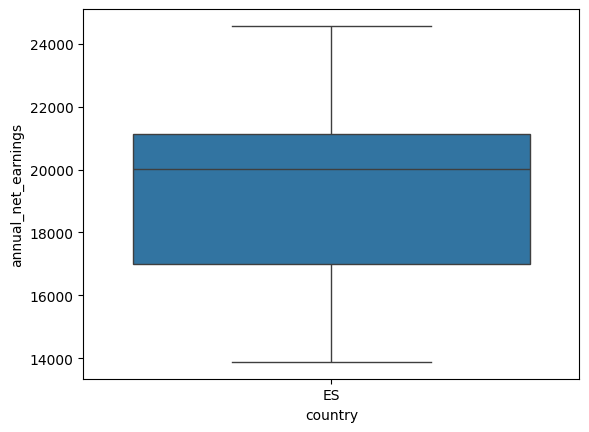

In [ ]:
df_sal_Es
sns.boxplot(data=df_sal_Es, x='country', y='annual_net_earnings')ñ

TASA DE DESEMPLEO

In [ ]:
# dataset tasa de desempleo anual
df_tasa_desempleo
df_tasa_desempleo.head()

,"freq,age,unit,sex,geo\TIME_PERIOD",2003,2004,2005,2006,2007,2008,2009,2010,2011,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,"A,Y15-74,PC_ACT,T,AT",:,:,:,:,:,:,5.7,5.2,4.9,...,6.5,5.9,5.2,4.8,6.0,6.2,4.8,5.1,5.2,5.7
1,"A,Y15-74,PC_ACT,T,BE",:,:,:,:,:,:,8.0,8.4,7.2,...,7.9,7.2 b,6.0,5.5,5.8,6.3,5.6,5.5,5.7,6.2
2,"A,Y15-74,PC_ACT,T,BG",:,:,:,:,:,:,7.9,11.3 b,12.3 b,...,8.6,7.2,6.2,5.2 b,6.1,5.2,4.2,4.3,4.2 b,3.5
3,"A,Y15-74,PC_ACT,T,CH",:,:,:,:,:,:,:,4.8 b,4.4,...,5.0,4.8,4.7,4.4,4.8,5.1,4.1,4.1,4.4,4.9
4,"A,Y15-74,PC_ACT,T,CY",:,:,:,:,:,:,5.4,6.3,7.9,...,13.0,11.1,8.4,7.2,7.6,7.2,6.3,5.8,4.9,4.4


In [ ]:
#1.HACER COPIA DEL DATAFRAME ORIGINAL df_tasa_desempleo
df_tasa_desempleo_clean = df_tasa_desempleo.copy()

In [409]:
#2. Renombro la primera columna "freq,age,unit,sex,geo\TIME_PERIOD" y la cambio a "info" para trabajar más fácil.
df_tasa_desempleo_clean = df_tasa_desempleo_clean.rename(columns={
    "freq,age,unit,sex,geo\TIME_PERIOD": "info"})
df_tasa_desempleo_clean

#3. Separo la columna Info en varias columnas:
df_tasa_desempleo_clean[['freq','age','unit','sex','country']] = df_tasa_desempleo_clean['info'].str.split(',', expand = True) #.str.split(',') → separa el texto por comas, y expand=TRue crea nuevas columnas
df_tasa_desempleo_clean

#4 Elimino  la columna original "info" (ya no la necesitamos):
df_tasa_desempleo_clean = df_tasa_desempleo_clean.drop(columns = ['info'],)
df_tasa_desempleo_clean

,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,...,2021,2022,2023,2024,2025,freq,age,unit,sex,country
0,:,:,:,:,:,:,5.7,5.2,4.9,5.2,...,6.2,4.8,5.1,5.2,5.7,A,Y15-74,PC_ACT,T,AT
1,:,:,:,:,:,:,8.0,8.4,7.2,7.6,...,6.3,5.6,5.5,5.7,6.2,A,Y15-74,PC_ACT,T,BE
2,:,:,:,:,:,:,7.9,11.3 b,12.3 b,13.3,...,5.2,4.2,4.3,4.2 b,3.5,A,Y15-74,PC_ACT,T,BG
3,:,:,:,:,:,:,:,4.8 b,4.4,4.5,...,5.1,4.1,4.1,4.4,4.9,A,Y15-74,PC_ACT,T,CH
4,:,:,:,:,:,:,5.4,6.3,7.9,11.9,...,7.2,6.3,5.8,4.9,4.4,A,Y15-74,PC_ACT,T,CY
5,:,:,:,:,:,:,6.7,7.3,6.7 b,7.0,...,2.8,2.2,2.6,2.6,2.8,A,Y15-74,PC_ACT,T,CZ
6,:,:,:,:,:,:,7.3,6.6 b,5.5 b,5.1,...,3.6,3.1,3.1,3.4,3.8,A,Y15-74,PC_ACT,T,DE
7,:,:,:,:,:,:,6.4,7.7,7.8,7.8,...,5.1,4.5,5.1 b,6.2,6.4,A,Y15-74,PC_ACT,T,DK
8,:,:,:,:,:,:,13.5,16.6,12.3,9.9,...,6.2,5.6,6.4,7.6,7.5,A,Y15-74,PC_ACT,T,EE
9,:,:,:,:,:,:,9.8,12.9,18.1,24.8,...,14.7,12.5,11.1,10.1,8.9,A,Y15-74,PC_ACT,T,EL


In [410]:
#5. Convertir el dataset de formato ancho a largo.
df_tasa_desempleo_clean = df_tasa_desempleo_clean.melt(
    id_vars=['freq','age','unit','sex','country'],
    var_name='year',
    value_name='unemployment_rate')
df_tasa_desempleo_clean

#6. Ordenamos los datos
df_tasa_desempleo_clean = df_tasa_desempleo_clean.sort_values(by= ['country','year']) 
df_tasa_desempleo_clean

,freq,age,unit,sex,country,year,unemployment_rate
0,A,Y15-74,PC_ACT,T,AT,2003,:
30,A,Y15-74,PC_ACT,T,AT,2004,:
60,A,Y15-74,PC_ACT,T,AT,2005,:
90,A,Y15-74,PC_ACT,T,AT,2006,:
120,A,Y15-74,PC_ACT,T,AT,2007,:
...,...,...,...,...,...,...,...
569,A,Y15-74,PC_ACT,T,SK,2021,6.8
599,A,Y15-74,PC_ACT,T,SK,2022,6.1
629,A,Y15-74,PC_ACT,T,SK,2023,5.8
659,A,Y15-74,PC_ACT,T,SK,2024,5.3


In [411]:
#7. Convierto el año a número entero, importante para gráficas y análisis.
df_tasa_desempleo_clean['year'] = df_tasa_desempleo_clean['year'].astype(int)
df_tasa_desempleo_clean

#8. Elimino las primeras 4 columnas , ya que en ellas no viene información relevante para mi análisis:
df_tasa_desempleo_clean = df_tasa_desempleo_clean.drop(df_tasa_desempleo_clean.columns[:4], axis=1) #axis 1 undica que son columnas
df_tasa_desempleo_clean

,country,year,unemployment_rate
0,AT,2003,:
30,AT,2004,:
60,AT,2005,:
90,AT,2006,:
120,AT,2007,:
...,...,...,...
569,SK,2021,6.8
599,SK,2022,6.1
629,SK,2023,5.8
659,SK,2024,5.3


In [412]:
#8.En columna unemployment_rate tengo valores con una "p" (valor provisional), valores " b" (break in series), ":" (no disponible) y " d"(definition differs) voy a quitarlos, haciendo los siguientes pasos:
#8.1. primero, pasar toda la columna a str por seguridad(porque mis datos viene mezclados,int,srt, text,símbolos,y si hago replace directamente me pueden dar error).
df_tasa_desempleo_clean["unemployment_rate"] = df_tasa_desempleo_clean["unemployment_rate"].astype(str)

#8.2 limpiar " p", " b" y " d":
df_tasa_desempleo_clean['unemployment_rate'] = (
    df_tasa_desempleo_clean['unemployment_rate']
    .str.replace(" p", "", regex=False) #quitar " p"
    .str.replace(" b", "", regex=False) #quitar " b"
    .str.replace(" d", "", regex=False) #quitar " d"
)
#8.2 Convertir ":"en NAn:
df_tasa_desempleo_clean['unemployment_rate'] = df_tasa_desempleo_clean['unemployment_rate'].replace(":", None) # con NON le estoy indicando que donde haya : se convierta en NAn(valor nulo)

#9. Convertir la columna unemployment_rate a numéro usando pd.to_numeric.
df_tasa_desempleo_clean['unemployment_rate'] = pd.to_numeric(df_tasa_desempleo_clean['unemployment_rate'], errors='coerce') #con errors='coerce' para que si hay  valores raros (:)me los convierta en NAn)


In [417]:
#9.1 una vez que he hecho la conversion, reviso cuántos valores NaN hay tras la conversion.
print(df_tasa_desempleo_clean.isna().sum())
#Con esto veo en que países y años tengo valores Nan.
# print(df_tasa_desempleo_clean[df_tasa_desempleo_clean["unemployment_rate"].isna()][["country", "year"]])

#Para verlo mejor, saco uan lista de todos los años donde hay NAn por país, para ello voy a hacer lo siguiente:
print(df_tasa_desempleo_clean[df_tasa_desempleo_clean['unemployment_rate'].isna()].groupby('country')['year'].apply(list))

#9.2 Elimino de mi dataset los países que no forman parte de la EU:
paises_fuera_UE =['UK', 'CH', 'NO', 'IS'] #defino mi lista de países a eliminar.
# Eliminamos esos países:
df_tasa_desempleo_clean = df_tasa_desempleo_clean[~df_tasa_desempleo_clean['country'].isin(paises_fuera_UE)]
df_tasa_desempleo_clean.isna().sum() #Miro a ver cuantos valores Nan me quedan.

country                0
year                   0
unemployment_rate    172
dtype: int64
country
AT          [2003, 2004, 2005, 2006, 2007, 2008]
BE          [2003, 2004, 2005, 2006, 2007, 2008]
BG          [2003, 2004, 2005, 2006, 2007, 2008]
CH    [2003, 2004, 2005, 2006, 2007, 2008, 2009]
CY          [2003, 2004, 2005, 2006, 2007, 2008]
CZ          [2003, 2004, 2005, 2006, 2007, 2008]
DE          [2003, 2004, 2005, 2006, 2007, 2008]
DK          [2003, 2004, 2005, 2006, 2007, 2008]
EE          [2003, 2004, 2005, 2006, 2007, 2008]
EL          [2003, 2004, 2005, 2006, 2007, 2008]
ES          [2003, 2004, 2005, 2006, 2007, 2008]
FI          [2003, 2004, 2005, 2006, 2007, 2008]
HR          [2003, 2004, 2005, 2006, 2007, 2008]
HU          [2003, 2004, 2005, 2006, 2007, 2008]
IE          [2003, 2004, 2005, 2006, 2007, 2008]
IS    [2003, 2004, 2005, 2006, 2007, 2008, 2025]
IT          [2003, 2004, 2005, 2006, 2007, 2008]
LT          [2003, 2004, 2005, 2006, 2007, 2008]
LU          [2003, 200

country                0
year                   0
unemployment_rate    152
dtype: int64

In [421]:
#9.2. Rellenar NAN con interpolación temporal por país ( creo que de esta manera es mas acertado que hacerlo con  media o mediana.)
'''Interpolación de valores faltantes (NaN) en la columna 'GDP_per:capita'
Agrupamos por 'country' y seleccionamos solo la columna 'GDP_per:capita'
 'transform' devuelve un resultado con el mismo índice que el DataFrame original.
lambda x: x.interpolate() es una funcion que rellena los huecos usando interpolación()
limit_direction="both" permite rellenar valores extremos, valores faltantes al principio y al final
'''
df_tasa_desempleo_clean['unemployment_rate'] = df_tasa_desempleo_clean.groupby('country')['unemployment_rate'].transform(lambda x: x.interpolate(limit_direction="both"))
df_tasa_desempleo_clean.info()
df_tasa_desempleo_clean.isna().sum() #compruebo que no haya quedado ningún valor nan.

<class 'pandas.DataFrame'>
Index: 621 entries, 0 to 689
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            621 non-null    str    
 1   year               621 non-null    int64  
 2   unemployment_rate  621 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 19.4 KB


country              0
year                 0
unemployment_rate    0
dtype: int64

In [ ]:
# MIro a ver cuantas filas y cols tiene este dataframe
print(df_tasa_desempleo_clean.shape)


(621, 3)


ANTES DE HACER EL MERGE DE TODOS LOS DATA SETS<br>

1.Primero sacar una lista del rango de años de todos los datasets, esto me ayudará a:<br>
Saber qué años coinciden en todos los datasets, para hacer el merge en ese rango de años.


In [432]:
#1.Saco una lista completa de años por dataset
years_inflatión = df_inflacion_long['year'].unique()
print("El rango de años del dataset inflación es: ", years_inflatión)

years_pib = df_pib_per_capita_clean['year'].unique()
print("El rango de años del dataset PIP_per_capita es: ", years_pib)

years_earnings =df_salario_neto_clean['year'].unique()
print("El rango de años del dataset salario_neto es: ", years_earnings)

years_unemployment = df_tasa_desempleo_clean['year'].unique()
print("El rango de años del dataset tasa_desempleo es: ", years_unemployment)

El rango de años del dataset inflación es:  [2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025]
El rango de años del dataset PIP_per_capita es:  [2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025]
El rango de años del dataset salario_neto es:  [2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
El rango de años del dataset tasa_desempleo es:  [2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016
 2017 2018 2019 2020 2021 2022 2023 2024 2025]


In [ ]:
"""
PRUEBA 1: Merge tipo INNER
# Este merge conserva solo las filas con datos completos en todos los datasets[2014 - 2024].
# Resultado: dataset con pocas filas (~297), insuficiente para el análisis requerido.
"""

df_prueba_inner = df_inflacion_long.merge(
    df_pib_per_capita_clean,
    on=['country', 'year'],
    how= 'inner' #solo conserva años y países comunes, es decir, de 2014-2024.
)
df_prueba_inner = df_prueba_inner.merge(
    df_salario_neto_clean,
    on=['country', 'year'],
    how='inner'
)
df_prueba_inner = df_prueba_inner.merge(
    df_tasa_desempleo_clean,
    on=['country', 'year'],
    how='inner'
)

# Revisamos tamaño y primeras filas
print(df_prueba_inner)
df_prueba_inner.head()

    country  year  inflation  GDP_per_capita  annual_net_earnings  \
0        AT  2014        1.5           129.0             27965.34   
1        AT  2015        0.8           128.0             28524.14   
2        AT  2016        1.0           128.0             30601.53   
3        AT  2017        2.2           125.0             31083.14   
4        AT  2018        2.1           126.0             31640.93   
..      ...   ...        ...             ...                  ...   
292      SK  2020        2.0            74.0             10250.84   
293      SK  2021        2.8            74.0             10982.50   
294      SK  2022       12.1            71.0             11846.85   
295      SK  2023       11.0            74.0             13027.56   
296      SK  2024        3.2            75.0             14069.86   

     unemployment_rate  
0                  6.0  
1                  6.1  
2                  6.5  
3                  5.9  
4                  5.2  
..                 ..

,country,year,inflation,GDP_per_capita,annual_net_earnings,unemployment_rate
0,AT,2014,1.5,129.0,27965.34,6.0
1,AT,2015,0.8,128.0,28524.14,6.1
2,AT,2016,1.0,128.0,30601.53,6.5
3,AT,2017,2.2,125.0,31083.14,5.9
4,AT,2018,2.1,126.0,31640.93,5.2


In [ ]:
# SOLUCIÓN: Merge tipo OUTER
""" Se utiliza para conservar el máximo número de observaciones
y posteriormente tratar los valores faltantes(NAn) mediante imputación
"""
df_merged = df_inflacion_long.merge(
    df_pib_per_capita_clean, on=["country", "year"], how="outer"
).merge(
    df_salario_neto_clean, on=["country", "year"], how="outer"
).merge(
    df_tasa_desempleo_clean, on=["country", "year"], how="outer"
)

print(df_merged.shape)
df_merged.head()


(702, 6)


,country,year,inflation,GDP_per_capita,annual_net_earnings,unemployment_rate
0,AT,2000,2.0,NaN,20525.86,NaN
1,AT,2001,2.3,NaN,20773.99,NaN
2,AT,2002,1.7,NaN,21179.51,NaN
3,AT,2003,1.3,NaN,21956.82,5.7
4,AT,2004,2.0,NaN,22004.46,5.7


In [442]:
#ver Nan por columna.
print(df_merged.isna().sum())
print(df_merged.isna().mean() * 100) # esto me devuelve porcentaje de nan

country                  0
year                     0
inflation                0
GDP_per_capita         378
annual_net_earnings     27
unemployment_rate       81
dtype: int64
country                 0.000000
year                    0.000000
inflation               0.000000
GDP_per_capita         53.846154
annual_net_earnings     3.846154
unemployment_rate      11.538462
dtype: float64


#Para rellenar los valores NAn, se aplica interpolacion“Se aplicó interpolación por país para estimar valores faltantes respetando la estructura temporal de los datos. Posteriormente, en caso de que sigan exisitendo NAn, se utilizará imputación mediante la media para completar aquellos valores que no pudieron ser estimados mediante interpolación.

In [ ]:
#interpolación por país

cols = ["inflation", "GDP_per_capita", "annual_net_earnings", "unemployment_rate"] # me defino las columnas sobre las que voy a interpolar

for col in cols:
    df_merged[col] = df_merged.groupby('country')[col].transform(
        lambda x: x.interpolate(limit_directions = "both")
    )

#compruebo resto de NAn
print(df_merged.isna().sum())
""" """

country                  0
year                     0
inflation                0
GDP_per_capita         378
annual_net_earnings      0
unemployment_rate       81
dtype: int64


In [ ]:
#rellenar lso valores NaN restantes utilizando la media por país.
"""Después de aplicar interpolación, algunos valores seguían siendo NaN,
 especialmente en los extremos de la serie temporal o en países con pocos datos.
# Para solucionarlo, se agrupan los datos por 'country' y se reemplazan
 los valores faltantes por la media de cada país en la variable correspondiente
 De este modo:
 - Se mantienen las diferencias estructurales entre países
 - Se evita eliminar datos (lo que reduciría el tamaño del dataset)
 - Se completa la serie para poder realizar análisis posteriores
"""
for col in cols:
    df_merged[col] = df_merged.groupby("country")[col].transform(
        lambda x: x.fillna(x.mean())
    )
    
#comprobar resultados
print(df_merged.isna().sum())
""" 
Tras aplicar la imputacion mediante la media por país, se observa que ya no quedan valores faltantes en las variables.
El dataset está ahora completo y listo para realizar el análisis exploratio(EDA).
"""


country                0
year                   0
inflation              0
GDP_per_capita         0
annual_net_earnings    0
unemployment_rate      0
dtype: int64


ANÁLISIS EXPLORATIO DE DATOS (EDA) <br>

In [ ]:
#1. Exploración inicial del Dataset
"""se utiliza los métodos info() y describe() de pandas para tener una visión general de los tipos de datos, 
la presencia de valores nulos, y los principales estadísticos descriptivos."""
df_merged.info()
"""
El dataset final contiene 702 filas, y 6 columnas.
se puede ver que todas las variables son numéricas son tipo float64, mientras que la variable temporal(año)
es de tipo entero.
No se observan valores nulos en todo el dataset, lo que indica que el proceso de limpieza ha sido completo.
"""

df_merged.describe().T
""" 
En los estadísticos descriptivos, se puede ver que:
    - La inflation presenta una media de 3.03%, con valores que oscilan entre -1.70% (deflación) y 45.70% lo que indica posible existencia de valores extremos.
    - El PIP per cápita muestra una media de 102.2
    - El salario neto annual tiene una media de 18.488€, lo que indica una existencia de difencias salariales entre países.
    - La tasa de desempleo tiene una media de 8.48%, con valores comprendidos entre 2% y 27.8%
En general los datos son coherentes, aunque se identifican posibles outliers que podrían requerir un análisis más detallado.

    
"""

<class 'pandas.DataFrame'>
RangeIndex: 702 entries, 0 to 701
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   country              702 non-null    str    
 1   year                 702 non-null    int64  
 2   inflation            702 non-null    float64
 3   GDP_per_capita       702 non-null    float64
 4   annual_net_earnings  702 non-null    float64
 5   unemployment_rate    702 non-null    float64
dtypes: float64(4), int64(1), str(1)
memory usage: 33.0 KB


,count,mean,std,min,25%,50%,75%,max
year,702.0,2012.500000,7.505348,2000.00,2006.000000,2012.500000,2019.000000,2025.00
inflation,702.0,3.026068,3.604624,-1.70,1.200000,2.300000,3.600000,45.70
GDP_per_capita,702.0,102.200617,42.818028,48.00,74.583333,90.416667,117.666667,280.00
annual_net_earnings,702.0,18488.962322,11031.331283,1670.31,8718.372500,17002.360000,26424.172500,50409.61
unemployment_rate,702.0,8.485990,4.051119,2.00,5.800000,7.600000,9.800000,27.80


ANÁLISIS TEMPRORAL de la Inflación

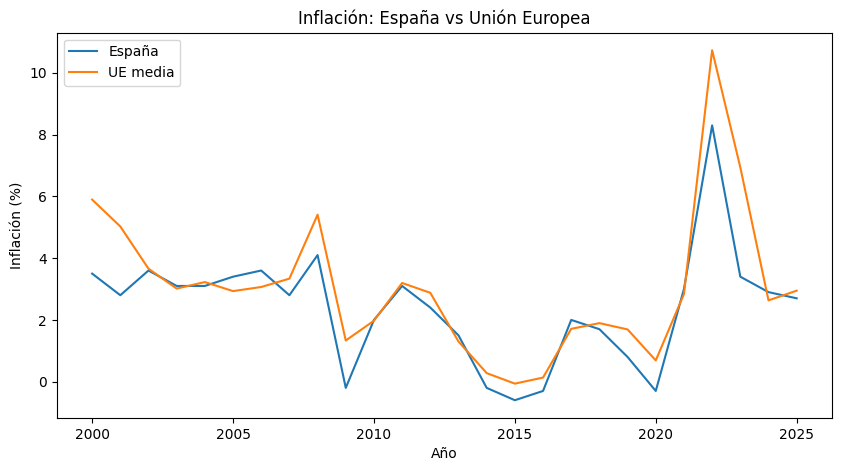

In [470]:
#2. Análisis temporal de inflacion España VS media UE

# DataFrame España
df_inflation_Es = df_merged[df_merged['country'] == "ES"][['year', 'inflation']] # filtro el dataframe para quedarme solo con el País "España"
df_inflation_Es

# DataFrame Inflation_UE

df_mean_inflation_UE =df_merged.groupby('year')['inflation'].mean().reset_index() #agrupa los datos por país, calcula la media de todos los pasies por inflation,y reset_index():devuelve el resultado como un dataframe. 

# Renombro la columna 'inflation'
df_mean_inflation_UE.rename(columns= {'inflation' : 'inflation_UE'}, inplace =  True)
df_mean_inflation_UE

# uno los dos dataFrames
df_plot_inflation = pd.merge(df_inflation_Es, df_mean_inflation_UE, on= 'year')
#representacion gráfica
plt.figure(figsize=(10,5))

sns.lineplot(data=df_plot_inflation, x="year", y="inflation", label="España")
sns.lineplot(data=df_plot_inflation, x="year", y="inflation_UE", label="UE media")

plt.title("Inflación: España vs Unión Europea")
plt.ylabel("Inflación (%)")
plt.xlabel("Año")

plt.legend()
plt.show()

Conclusión: con este gráfco quiero ver como se comporta la inflacion en españa vs la Union europea. En general se puede ver que la inflación en España sigue una evolución muy parecida a la de la Unión europea,
Ambos presentan estabilidad antes de 2008, una fuerte caída durante la crisis financiera, y un periodo prolongado de baja inflación hasta 2020.A partir de 2021 se observa un fuerte incremento de iflación en ambos casos, alcanzando su pico en 2022, aunque la media de la UE supera ligeramente a España.


Análisis del PIB per capita <br>

In [ ]:
# PIB per cápita ESPAÑA VS UE.
#1. crear dataframe PIB españa.
df_pib_Es =df_merged[df_merged['country'] == "ES"][['year', 'GDP_per_capita']].sort_values('year')

# print(df_pib_Es)

#2. Media PIB Union Europea
df_pib_mean_UE = (
    df_merged.groupby('year')['GDP_per_capita']  # agrupa por año
    .mean()  # calcula media UE
    .reset_index()  # convierte en DataFrame
    .rename(columns={'GDP_per_capita': 'gdp_per_capita_UE'})  # renombra columna
)
# print(df_pib_mean_UE)

# junto los dos dataframes mediante merge
df_plot_pib = pd.merge(df_pib_Es, df_pib_mean_UE, on= 'year')
# print(df_plot_pib)

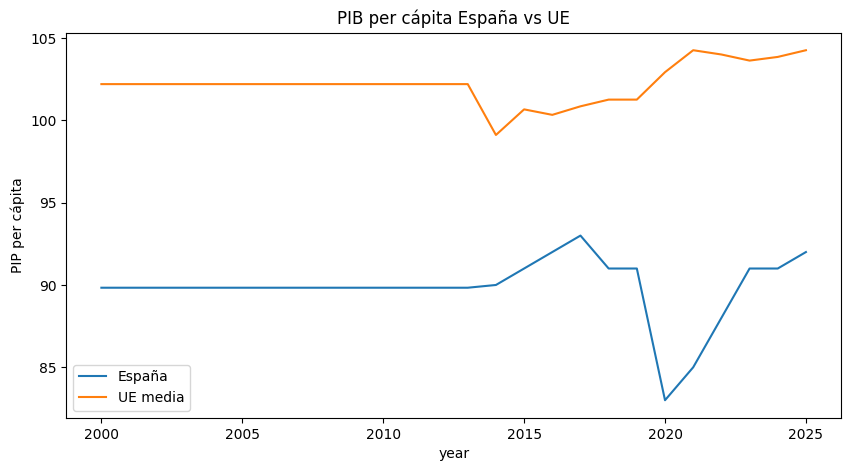

In [493]:
#Representacion gráfica GDP_per_capita España vs Media UE
plt.figure(figsize=(10,5))

sns.lineplot(data=df_plot_pib, x="year", y="GDP_per_capita", label="España")
sns.lineplot(data=df_plot_pib, x="year", y="gdp_per_capita_UE", label="UE media")

plt.title("PIB per cápita España vs UE")
plt.ylabel("PIP per cápita")
# plt.xlabel("Año")

# plt.legend()
plt.show()

conclusion: El gráfico muestra la evolución del PIB per cápita en España en comparación con la media de la Unión Europea a lo largo del periodo analizado.

Se observa que entre los años 2000 y 2014 el PIB per cápita se mantiene prácticamente constante. Esto no refleja la evolución real de la variable, sino que se debe a la falta de datos originales en el dataset para ese periodo (el dataset comienza en 2014). Para completar los valores faltantes, se han aplicado técnicas de interpolación y, en los extremos, imputación mediante la media, lo que genera valores planos o suavizados.

A partir de 2014, donde ya se dispone de datos reales, se observa una evolución más representativa. En este periodo, España muestra una ligera tendencia creciente en el PIB per cápita, aunque se mantiene por debajo de la media de la Unión Europea. Destaca también una caída significativa en 2020, probablemente asociada al impacto económico de la pandemia(covid-19).


ANÁLISIS PIB PER CAPITA EN RELACION CON LA INFLACIÓN 


Se analiza la relación entre la inflación y el PIB per cápita mediante gráficos de dispersión, con el objetivo de evaluar si existe una relación inversa entre ambas variables.

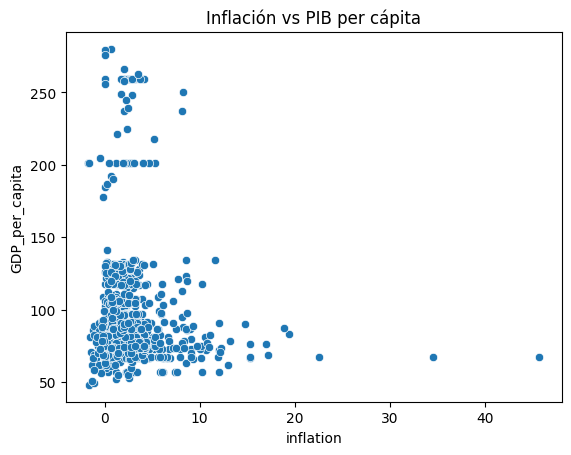

In [494]:
sns.scatterplot(data=df_merged, x="inflation", y="GDP_per_capita")
plt.title("Inflación vs PIB per cápita")
plt.show()

Conclusion: El gráfico de dispersión muestra la relación entre la inflación y el PIB per cápita para los distintos países y años del dataset.

Se observa una alta dispersión de los datos, sin una tendencia clara que indique una relación directa entre ambas variables. La mayoría de los valores se concentran en niveles de inflación moderados (entre 0% y 10%) y PIB per cápita intermedio.

En algunos casos extremos, se aprecia que niveles muy altos de inflación pueden asociarse a valores más bajos de PIB per cápita, aunque esta relación no es consistente en el conjunto de los datos.

Por tanto, no se puede concluir una relación directa y significativa entre inflación y PIB per cápita. Esto puede deberse a que el PIB per cápita no es un indicador directo del poder adquisitivo individual, por lo que no refleja completamente el impacto de la inflación sobre la población.

Para complementar el análisis global, se realiza un estudio específico para España, con el objetivo de observar de forma más precisa la relación entre inflación y PIB per cápita.

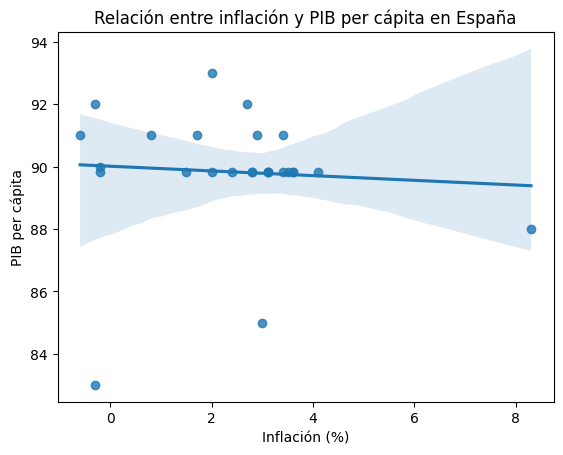

In [ ]:
# Scatter solo España: relacion inflacion vs PIB per cápita

#filtarar dataframe solo por españa
df_es = df_merged[df_merged['country'] == "ES"]

#SCATTERPLOT + LINEA DE TENDENCIA

sns.regplot(data=df_es, x="inflation", y="GDP_per_capita")

plt.title("Relación entre inflación y PIB per cápita en España")
plt.xlabel("Inflación (%)")
plt.ylabel("PIB per cápita")

plt.show()



Conclusion: como se peude ver en el gráfico de dispersion, la linea de tendencia es ligeramente descendente, esto quiere decir que, a medida que aumenta la inflación, el PIB per cápita tiende ligeramente a disminuir. Sin embargo, la relacion observada es debil,ya que los puntos estan muy dispersos, por tanto no se puede afirmar que existe una relacion fuerte entre ambas variables en el periodo analizado.

Este resultado indica que el PIB per cápita no refleja de forma directa el impacto de la inflacion. por lo que será necesario completar el analisis con la variable salario neto qe tiene realcion directa con el poder adquisitivo.

ANÁLISIS INFLACIÓN VS SALARIOS

El objetivo aqui es ver si la inflación afecta a los salarios y por tanto al poder asquisitivo de la población.

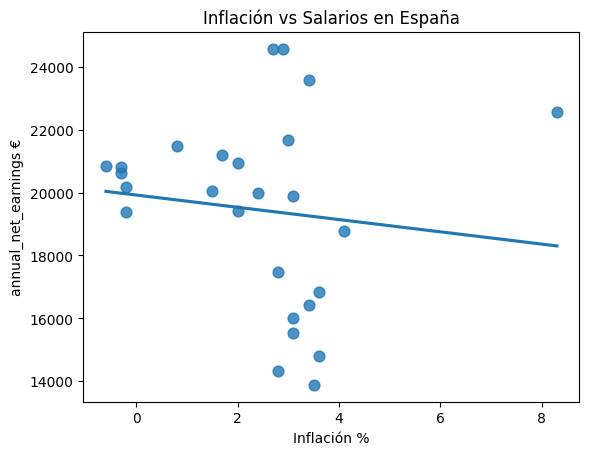

In [550]:
# Filtrar el DataFrame solo por España
df_sal_Es = df_merged[df_merged['country'] == 'ES']

#Scatter Inflación vs SALARIOS
sns.regplot(
    data= df_sal_Es, ## DataFrame filtrado únicamente para España
    x='inflation', ## Variable independiente (eje X): tasa de inflación
    y='annual_net_earnings', ## Variable dependiente (eje Y): salario neto anual
    ci=None, #quitar intervalos de confianza (para una visualización más limpia)
    scatter_kws={"s": 60} # me ajusta el tamaño de los puntos apra que vean mejor.
)

plt.title("Inflación vs Salarios en España")
plt.xlabel("Inflación %")
plt.ylabel("annual_net_earnings €")
plt.show()

Conclusión: se observa una ligera tendencia negativa de regresion lineal entre las variables, lo que indica que a medida que aumenta la inflación,  los salarios no aumentan de forma proporcional. Sin embargo, tambien se puede observar, que la dispersion de los datos es bastante alta, lo que sugiere que no existe relación fuerte entre ambas variables.Es decir, la inflación no influye de manera significativa en la variacion de los salarios, ya que probablemente intervienen otros factores económicos.
POr tanto, la hipótesis planteada arriba se apoya de forma parcial, pero no puede confrimarse de manera segura con los datos disponibles.

In [ ]:
#Analisis infllacion vs salrios media UE
# Salario neto anual medio UE
df_mean_sal_UE =(
    df_merged.groupby('year')['annual_net_earnings']
    .mean()
    .reset_index()
    .rename(columns={'annual_net_earnings': 'salary_UE'})
)
# print(df_mean_sal_UE)
#Inflacion media UE: 
df_mean_inflation_UE # ya está definida arriba

#uno los dos DAtaFrames
df_sal_infl_UE =pd.merge(df_mean_sal_UE, df_mean_inflation_UE, on= 'year')
# print(df_sal_infl_UE)

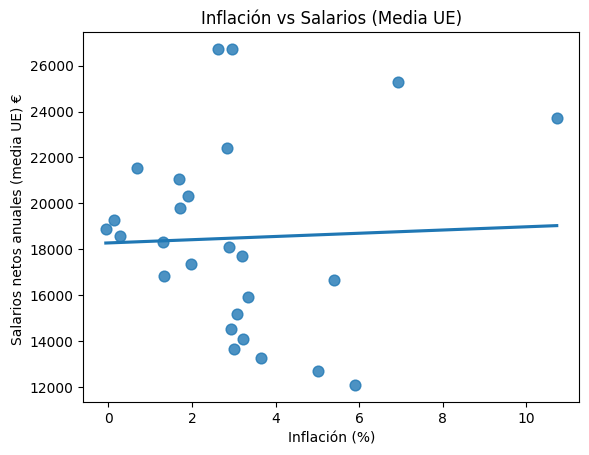

In [552]:
#Gráfico inflacion VS salarios UE

sns.regplot(
    data=df_sal_infl_UE,
    x="inflation_UE",
    y="salary_UE",
    ci=None,
    scatter_kws={"s": 60}
)

plt.title("Inflación vs Salarios (Media UE)")
plt.xlabel("Inflación (%)")
plt.ylabel("Salarios netos anuales (media UE) € ")

plt.show()

Conclusión: El análisis de regresión entre inflación y salario medio anual en la UE muestra una relación lineal positiva débil. Aunque los países con mayor inflación tienden a presentar salarios ligeramente más altos, la dispersión de los datos indica que la inflación no es un factor determinante en el nivel salarial. Esto sugiere que otros elementos económicos, como la productividad o el nivel de desarrollo, influyen más significativamente en los ingresos medios.

ANALISIS DE LA RELACION ENTRE INFLACION Y DESEMPLEO

EL objetivo aqui ver si existe alguna relacion entre ambas variables, que confirme la teoria economica. 

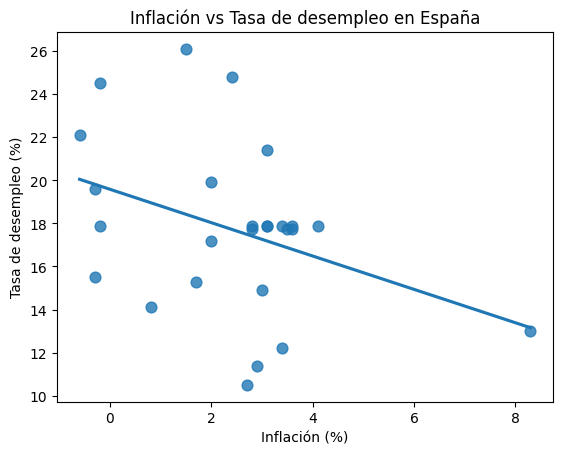

In [ ]:
#AnálisiS inflacion vs tasa de desempleo en ESPAÑA
# Filtrar DataFrame solo por España
df_Es = df_merged[df_merged['country'] == "ES"]

#SCATTERPLOT

sns.regplot(
    data=df_es,
    x="inflation",
    y="unemployment_rate",
    ci=None,
    scatter_kws={"s": 60}
)

plt.title("Inflación vs Tasa de desempleo en España")
plt.xlabel("Inflación (%)")
plt.ylabel("Tasa de desempleo (%)")

plt.show()

In [521]:
df_Es[['inflation','unemployment_rate']].corr()

,inflation,unemployment_rate
inflation,1.000000,-0.369476
unemployment_rate,-0.369476,1.000000


Conclusión: Se peude observar que en el caso de España la linea de tendencia es negatica, lo que implica que existe una relacion inversa entre variables inflacion y desempleo, es decir que cuando sube inflacion, el desempleo tiende a disminuir.
Por otro lado, se observa que los puntos presentan una alta dispersion, se observan algunos valores atípicos, donde:<br>
    -Años con inflación baja pero desempleo alto<br>
    -Y otros con inflación media y desempleo bajo<br>
En resumen, aunque la tendencia general apoya la teoria económica(curva de philips), se puede observar con los datos del estudio que la relación no es fuerte, ni consistente.

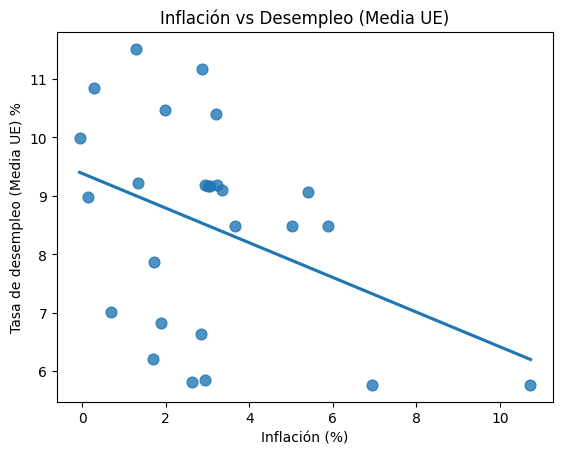

In [553]:
##AnálisiS inflacion vs tasa de desempleo UE

#Crear tasa de desempleo media de la UE
df_unemp_UE =(
    df_merged.groupby('year')['unemployment_rate']
    .mean() #hace la media de la UE
    .reset_index()# me devuelve el dataframe 
    .rename(columns={"unemployment_rate": "unemployment_UE"}) #renombra la columna
)

# DataFrame Inflation_UE 
df_mean_inflation_UE # variable ya creada arriba)

#Unir las dos variables inflacion UE y desempleo UE:
 
df_ue_infl_unemp = pd.merge(df_unemp_UE, df_mean_inflation_UE, on= 'year')
df_ue_infl_unemp

#scatterplot UE

sns.regplot(
    data=df_ue_infl_unemp,
    x="inflation_UE",
    y="unemployment_UE",
    ci=None,
    scatter_kws={"s": 60}
)

plt.title("Inflación vs Desempleo (Media UE)")
plt.xlabel("Inflación (%)")
plt.ylabel("Tasa de desempleo (Media UE) %")
plt.show()

Conclusión: En el caso de Unión Europea, el gráfico muestra una relacion inversa entre inflación y tasa de desempleo. La linea de regresion tiene pendiente negativa, algo más pronunciada que en el caso de España. aún así, los datos prensenda cierta dispersion.
Se puede concluir con esto que la relación inversa parece más consistente a nivel agregado (UE) que a nivel individual (España).

MATRÍZ DE CORRELACIÓN ENTRE TODAS LAS VARIABLES

In [527]:
#1. selecionar variables 

df_corr = df_merged[['inflation', 'GDP_per_capita', 'annual_net_earnings', 'unemployment_rate']].corr()

df_corr





,inflation,GDP_per_capita,annual_net_earnings,unemployment_rate
inflation,1.000000,-0.144495,-0.196423,-0.129498
GDP_per_capita,-0.144495,1.000000,0.743062,-0.259424
annual_net_earnings,-0.196423,0.743062,1.000000,-0.282507
unemployment_rate,-0.129498,-0.259424,-0.282507,1.000000


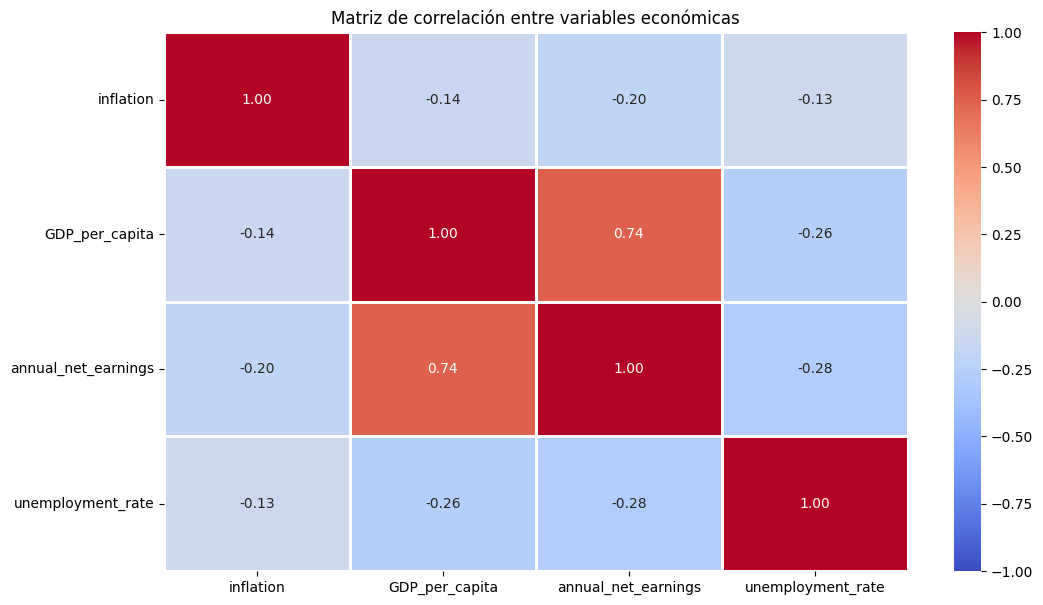

In [ ]:
# Matriz de correlaciones o heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(
   df_corr,
    annot=True, # muestra los valores dentro de cada celda
    vmin= -1, # valor mínimo de la escala (correlación negativa)
    vmax= 1, # valor máximo de la escala (correlación positiva)
    cmap="coolwarm", # paleta de colores (azul = negativo, rojo = positivo)
    fmt=".2f",        #formato de los números (2 decimales)
    linewidths=1 #define el grosor de las líneas que separan las celdas del heatmap
)

plt.title("Matriz de correlación entre variables económicas")
plt.show()

In [ ]:
Conclusion: 
La matriz de correlación muestra que la única relación lineal fuerte del conjunto de datos es la existente entre el PIB per cápita y los ingresos netos anuales (r = 0.74), lo que indica que los países con mayor nivel de riqueza presentan también salarios más elevados. El resto de correlaciones presentan valores bajos (entre –0.28 y –0.13), lo que sugiere relaciones lineales débiles entre inflación, desempleo y las variables económicas principales. En conjunto, los datos indican que no existen patrones lineales fuertes más allá de la relación entre riqueza y nivel salarial.